<a href="https://colab.research.google.com/github/Chaitralikore/Remote-Sensing/blob/main/Image_classification_(Supervised_unsupervised)_techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

project name: Image classification
Project ID: image-classification-495500


---

https://developers.google.com/earth-engine


---

https://console.cloud.google.com/earth-engine/configuration;success-registration=true?project=image-classification-495500

Generating URL ...
Please wait ...
Data downloaded to /content/cluster_result.tif
Displaying exported classification result...


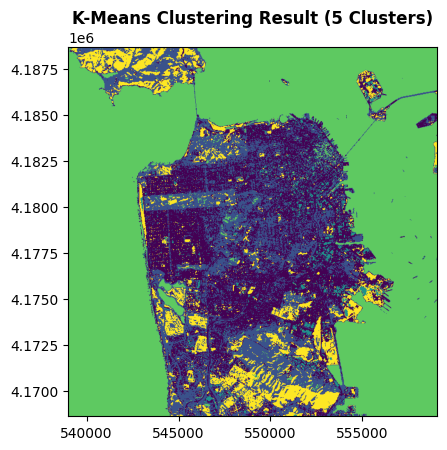

In [2]:
## Import libraries
import ee
import geemap
import os
import rasterio as rio
from rasterio.plot import show

## Authenticate and Initialize ee
# Ensure you have enabled the "Earth Engine API" in your Google Cloud Console
ee.Authenticate()
ee.Initialize(project='image-classification-495500')

## 1. Define the Area of Interest
point = ee.Geometry.Point([-122.4439, 37.7538])
# Create a 10km buffer around the point for a valid analysis region
region = point.buffer(10000).bounds()

## 2. Load and Filter Landsat-8 Data
image = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(point)
    .filterDate("2023-01-01", "2023-12-31")
    .sort("CLOUD_COVER")
    .first()
    .select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7'])
)

# Visualization parameters (False Color Composite)
vis_params = {"min": 0, "max": 3000, "bands": ["SR_B5", "SR_B4", "SR_B3"]}

Map = geemap.Map()
Map.centerObject(point, 11)
Map.addLayer(image, vis_params, "Landsat-8 Original")

## 3. Create Training Dataset
# We sample pixels within the defined region to train the clusterer
training = image.sample(
    **{
        "region": region,
        "scale": 30,
        "numPixels": 5000,
        "seed": 0,
        "geometries": True,
    }
)

## 4. Train Clusterer (K-Means)
n_clusters = 5
clusterer = ee.Clusterer.wekaKMeans(n_clusters).train(training)

## 5. Apply Classification
result = image.cluster(clusterer)

# Display the clusters with random colors
Map.addLayer(result.randomVisualizer(), {}, "Unsupervised Clusters")
Map

## 6. Export Result to Colab Local Storage
# Using '/content' is necessary for Colab to avoid permission errors
out_dir = "/content"
out_file = os.path.join(out_dir, "cluster_result.tif")

# Clipping the result to our region prevents "Export too large" errors
geemap.ee_export_image(
    result.clip(region),
    filename=out_file,
    scale=30,
    region=region
)

## 7. Display Result using Rasterio
if os.path.exists(out_file):
    with rio.open(out_file) as src:
        print("Displaying exported classification result...")
        show(src, title="K-Means Clustering Result (5 Clusters)")
else:
    print("File export failed. Please check your GEE Task tab or reduce the region size.")

Unsupervised Classification (K-Means)
● K-means is a clustering algorithm that partitions pixels into K distinct groups. ● It minimizes the within-cluster spectral variance.
● Each pixel is assigned to the nearest cluster centroid.
Why use it?
● No labeled data needed.
● Useful for initial land cover exploration
Workflow Summary
- Load Landsat-8 image using Google Earth Engine (GEE).
- Select useful spectral bands for land cover (B1–B7).
- Sample image pixels using .sample() to create an unsupervised training dataset. - Train a KMeans clusterer using ee.Clusterer.wekaKMeans(k)
- Apply clustering to the entire image.
- Visualize the results using geemap.
- Export the classified image to local storage or Google Drive. - Analyze clusters using tools like rasterio, numpy, and matplotlib
Applications
● Land cover/land use mapping
● Urban vs. vegetation zone detection
● Preliminary classification before supervised labeling
● Identifying patterns of environmental change
Limitations
● Cluster labels are arbitrary and must be interpreted manually. ● No ground truth = potential misclassification.
● Sensitive to initial K value and spectral overlap.
a) Supervised Classification:
- Analyst provides training data (labeled examples).
- Algorithms learn from these examples to classify the rest of the image. Common Algorithms:
● Maximum Likelihood
● Minimum distance to mean
● parallelepiped
Pros: Higher accuracy with good training data
Cons: Needs labeled data (time-consuming)
b) Unsupervised Classification
● No training data provided.
● Algorithm clusters pixels based on spectral similarity.
Common Algorithms:
● K-Means Clustering
● ISODATA
Pros: Fully automated, quick initial classification Cons: Classes are unnamed and need manual interpretation
